In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import matplotlib.pyplot as plt

In [ ]:
# 1. Load IMDb Dataset

vocab_size = 10000
maxlen = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 2. RNN Model

rnn_model = Sequential([
    Embedding(vocab_size, 32, input_length=maxlen),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

print("\nTraining RNN Model...")
rnn_history = rnn_model.fit(x_train, y_train,
                            epochs=3,
                            batch_size=64,
                            validation_split=0.2)



Training RNN Model...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.6562 - loss: 0.6073 - val_accuracy: 0.7272 - val_loss: 0.5435
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8399 - loss: 0.3801 - val_accuracy: 0.8474 - val_loss: 0.3617
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9089 - loss: 0.2301 - val_accuracy: 0.8444 - val_loss: 0.4075


In [ ]:
# 3. LSTM Model

lstm_model = Sequential([
    Embedding(vocab_size, 32, input_length=maxlen),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

print("\nTraining LSTM Model...")
lstm_history = lstm_model.fit(x_train, y_train,
                              epochs=3,
                              batch_size=64,
                              validation_split=0.2)



Training LSTM Model...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - accuracy: 0.7773 - loss: 0.4505 - val_accuracy: 0.8504 - val_loss: 0.3541
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.9032 - loss: 0.2479 - val_accuracy: 0.8638 - val_loss: 0.3273
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.9316 - loss: 0.1827 - val_accuracy: 0.8548 - val_loss: 0.3427


In [ ]:
# 4. GRU Model

gru_model = Sequential([
    Embedding(vocab_size, 32, input_length=maxlen),
    GRU(32),
    Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

print("\nTraining GRU Model...")
gru_history = gru_model.fit(x_train, y_train,
                            epochs=3,
                            batch_size=64,
                            validation_split=0.2)




Training GRU Model...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 70ms/step - accuracy: 0.7620 - loss: 0.4657 - val_accuracy: 0.8342 - val_loss: 0.3954
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.8997 - loss: 0.2572 - val_accuracy: 0.8702 - val_loss: 0.3134
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.9272 - loss: 0.1955 - val_accuracy: 0.8758 - val_loss: 0.3232


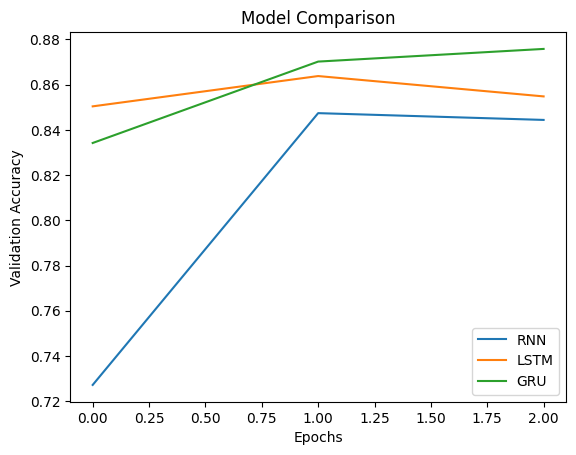

In [ ]:
# 5. Compare Learning Curves

plt.plot(rnn_history.history['val_accuracy'], label='RNN')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM')
plt.plot(gru_history.history['val_accuracy'], label='GRU')

plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()



In [ ]:
# 6. Test Accuracy

print("\nTest Accuracy")

print("RNN :", rnn_model.evaluate(x_test, y_test)[1])
print("LSTM :", lstm_model.evaluate(x_test, y_test)[1])
print("GRU :", gru_model.evaluate(x_test, y_test)[1])


Test Accuracy
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8388 - loss: 0.4058
RNN : 0.8387600183486938
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8534 - loss: 0.3449
LSTM : 0.85343998670578
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8635 - loss: 0.3414
GRU : 0.8634799718856812
